In [1]:
%%capture cap
%run ./src/desp-authentication.py -u "" -p ""

In [2]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]


In [3]:
S3_KEY = ""
S3_SECRET = ""

In [4]:
import earthkit.data
import earthkit.plots
import earthkit.geo.cartography

import logging, warnings
import earthkit.data

# Disable earthkit disk cache (polytope_zarr caches decoded arrays in memory)
earthkit.data.config.set("cache-policy", "off")

# Silence verbose output from polytope / earthkit internals
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from polytope_zarr import PolytopeZarrStore

import s3fs
import io

In [5]:
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

True

In [6]:
eodc_s3 = s3fs.S3FileSystem(
    key=S3_KEY,
    secret=S3_SECRET,
    client_kwargs={
        "endpoint_url": "https://objects.eodc.eu"
    })

path = "destine-climate-dt/vsw/netcdf"

In [7]:
COUNTRY = "Austria"
shapes = earthkit.geo.cartography.country_polygons([COUNTRY], resolution=50e6)

In [8]:
# ── Configuration ─────────────────────────────────────────────────

experiment = "hist"

hist_store = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment="hist",
    resolution="high", # 'standard', 'high'
    levtype="sol",
    frequency="hourly",
    start_date="1990-01-01T00:00:00",
    end_date="2014-12-31T23:00:00",
)

print(hist_store)
hist_store._filter_hours = [12]

<PolytopeZarrStore 2 variables (time=219144, cell=12582912, model=3, level=5)>


In [9]:
ds_hist = hist_store.open()
ds_hist

<xarray.Dataset> Size: 331TB
Dimensions:  (cell: 12582912, level: 5, model: 3, time: 219144)
Coordinates:
  * cell     (cell) int32 50MB 0 1 2 3 4 ... 12582908 12582909 12582910 12582911
  * level    (level) int32 20B 1 2 3 4 5
  * model    (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time     (time) datetime64[ns] 2MB 1990-01-01 ... 2014-12-31T23:00:00
Data variables:
    sd       (model, time, level, cell) float32 165TB ...
    vsw      (model, time, level, cell) float32 165TB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 2 variables (time=219144, cell=12582...

In [11]:
model = "ICON"
level = 1
# vsw_icon = ds_hist["vsw"].polytope.sel(model=model, time=slice("2002-01-01", "2002-01-31"), level=level, polygon=shapes)
vsw_icon = ds_hist["vsw"].polytope.sel(model=model, time=slice("2002-01-01", "2002-01-03"), level=level, area=[49.0758, 9.4979, 46.308, 17.2416])

  🌍 area request for vsw (20020101/to/20020103, area=49.0758/9.4979/46.308/17.2416, grid=0.05/0.05)


In [12]:
vsw_icon

<xarray.Dataset> Size: 210kB
Dimensions:    (time: 3, latitude: 56, longitude: 155)
Coordinates:
  * time       (time) datetime64[ns] 24B 2002-01-01T12:00:00 ... 2002-01-03T1...
  * latitude   (latitude) float64 448B 49.06 49.01 48.96 ... 46.41 46.36 46.31
  * longitude  (longitude) float64 1kB 9.498 9.548 9.598 ... 17.1 17.15 17.2
Data variables:
    vsw        (time, latitude, longitude) float64 208kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [ ]:
model = "IFS-FESOM"
level = 1
vsw = ds_hist["vsw"].polytope.sel(model=model, time=slice("2012-01-01", "2012-01-31"), level=level, polygon=shapes)

  🌍 polygon request for vsw (20120101/to/20130131)


In [31]:
vsw

<xarray.Dataset> Size: 579kB
Dimensions:    (time: 31, points: 2067)
Coordinates:
  * time       (time) datetime64[ns] 248B 2012-01-01T12:00:00 ... 2012-01-31T...
  * points     (points) int64 17kB 0 1 2 3 4 5 ... 2061 2062 2063 2064 2065 2066
    latitude   (points) float64 17kB 46.42 46.42 46.47 ... 48.97 48.97 48.97
    longitude  (points) float64 17kB 14.45 14.55 14.08 14.18 ... 15.0 15.1 15.31
    levelist   (points) float64 17kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
Data variables:
    vsw        (time, points) float64 513kB 0.4107 0.3881 ... 0.4017 0.3996
Attributes: (12/16)
    activity:     baseline
    class:        d1
    dataset:      climate-dt
    experiment:   hist
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2012-01-01 12:00:00Z

In [ ]:
data_bytes = vsw.to_netcdf()  # no path → returns bytes
with eodc_s3.open(f"{path}/vsw_{model}_{experiment}_level{level}.nc", "wb") as f:
    f.write(data_bytes)
    print(f"{path}/vsw_{model}_{experiment}_level{level}.nc")

destine-climate-dt/vsw/netcdf/test/vsw_IFS-FESOM_hist_level1.nc


In [11]:
model = "IFS-NEMO"
level = 1
vsw_nemo = ds_hist["vsw"].polytope.sel(model=model, time=slice("2012-01-01", "2012-01-31"), level=level, polygon=shapes)

  🌍 polygon request for vsw (20120101/to/20120131)


In [12]:
vsw_nemo

<xarray.Dataset> Size: 579kB
Dimensions:    (time: 31, points: 2067)
Coordinates:
  * time       (time) datetime64[ns] 248B 2012-01-01T12:00:00 ... 2012-01-31T...
  * points     (points) int64 17kB 0 1 2 3 4 5 ... 2061 2062 2063 2064 2065 2066
    latitude   (points) float64 17kB 46.42 46.42 46.47 ... 48.97 48.97 48.97
    longitude  (points) float64 17kB 14.45 14.55 14.08 14.18 ... 15.0 15.1 15.31
    levelist   (points) float64 17kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
Data variables:
    vsw        (time, points) float64 513kB 0.4099 0.407 ... 0.3909 0.3807
Attributes: (12/16)
    activity:     baseline
    class:        d1
    dataset:      climate-dt
    experiment:   hist
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2012-01-01 12:00:00Z

In [ ]:
data_bytes = vsw_nemo.to_netcdf()  # no path → returns bytes
with eodc_s3.open(f"{path}/vsw_{model}_{experiment}_level{level}.nc", "wb") as f:
    f.write(data_bytes)
    print(f"{path}/vsw_{model}_{experiment}_level{level}.nc")

destine-climate-dt/vsw/netcdf/test/vsw_IFS-NEMO_hist_level1.nc


In [11]:
vsw_icon

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 31, latitude: 56, longitude: 155)
Coordinates:
  * time       (time) datetime64[ns] 248B 2002-01-01T12:00:00 ... 2002-01-31T...
  * latitude   (latitude) float64 448B 49.06 49.01 48.96 ... 46.41 46.36 46.31
  * longitude  (longitude) float64 1kB 9.498 9.548 9.598 ... 17.1 17.15 17.2
Data variables:
    vsw        (time, latitude, longitude) float64 2MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [ ]:
data_bytes = vsw_icon.to_netcdf()  # no path → returns bytes
with eodc_s3.open(f"{path}/vsw_{model}_{experiment}_level{level}.nc", "wb") as f:
    f.write(data_bytes)
    print(f"{path}/vsw_{model}_{experiment}_level{level}.nc")

destine-climate-dt/vsw/netcdf/test/vsw_ICON_hist_level1.nc


In [ ]:

experiment = "SSP3-7.0"

proj_store = PolytopeZarrStore.from_climate_dt(
    models=["ICON", "IFS-FESOM", "IFS-NEMO"],
    experiment=experiment,
    resolution="high", # 'standard', 'high'
    levtype="sol",
    frequency="hourly",
    start_date="2015-01-01T00:00:00",
    end_date="2049-12-31T23:00:00",
)

print(proj_store)
proj_store._filter_hours = [12]

<PolytopeZarrStore 2 variables (time=219144, cell=12582912, model=3, level=5)>


In [46]:
ds_proj = proj_store.open()
ds_proj

<xarray.Dataset> Size: 331TB
Dimensions:  (cell: 12582912, level: 5, model: 3, time: 219144)
Coordinates:
  * cell     (cell) int32 50MB 0 1 2 3 4 ... 12582908 12582909 12582910 12582911
  * level    (level) int32 20B 1 2 3 4 5
  * model    (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time     (time) datetime64[ns] 2MB 2015-01-01 ... 2039-12-31T23:00:00
Data variables:
    sd       (model, time, level, cell) float32 165TB ...
    vsw      (model, time, level, cell) float32 165TB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 2 variables (time=219144, cell=12582...

In [47]:
model = "IFS-FESOM"
level = 1
vsw_fesom = ds_proj["vsw"].polytope.sel(model=model, time=slice("2018-01-01", "2018-01-31"), level=level, polygon=shapes)
vsw_fesom

  🌍 polygon request for vsw (20180101/to/20180131)


<xarray.Dataset> Size: 579kB
Dimensions:    (time: 31, points: 2067)
Coordinates:
  * time       (time) datetime64[ns] 248B 2018-01-01T12:00:00 ... 2018-01-31T...
  * points     (points) int64 17kB 0 1 2 3 4 5 ... 2061 2062 2063 2064 2065 2066
    latitude   (points) float64 17kB 46.42 46.42 46.47 ... 48.97 48.97 48.97
    longitude  (points) float64 17kB 14.45 14.55 14.08 14.18 ... 15.0 15.1 15.31
    levelist   (points) float64 17kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
Data variables:
    vsw        (time, points) float64 513kB 0.3912 0.3847 ... 0.367 0.3749
Attributes: (12/16)
    activity:     projections
    class:        d1
    dataset:      climate-dt
    experiment:   ssp3-7.0
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2018-01-01 12:00:00Z

In [ ]:
data_bytes = vsw_fesom.to_netcdf()  # no path → returns bytes
with eodc_s3.open(f"{path}/vsw_{model}_{experiment}_level{level}.nc", "wb") as f:
    f.write(data_bytes)
    print(f"{path}/vsw_{model}_{experiment}_level{level}.nc")

destine-climate-dt/vsw/netcdf/test/vsw_IFS-FESOM_SSP3-7.0_level1.nc


In [50]:
model = "IFS-NEMO"
level = 1
vsw_nemo = ds_proj["vsw"].polytope.sel(model=model, time=slice("2018-01-01", "2018-01-31"), level=level, polygon=shapes)
vsw_nemo

  🌍 polygon request for vsw (20180101/to/20180131)


<xarray.Dataset> Size: 579kB
Dimensions:    (time: 31, points: 2067)
Coordinates:
  * time       (time) datetime64[ns] 248B 2018-01-01T12:00:00 ... 2018-01-31T...
  * points     (points) int64 17kB 0 1 2 3 4 5 ... 2061 2062 2063 2064 2065 2066
    latitude   (points) float64 17kB 46.42 46.42 46.47 ... 48.97 48.97 48.97
    longitude  (points) float64 17kB 14.45 14.55 14.08 14.18 ... 15.0 15.1 15.31
    levelist   (points) float64 17kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
Data variables:
    vsw        (time, points) float64 513kB 0.3894 0.3904 ... 0.3553 0.3522
Attributes: (12/16)
    activity:     projections
    class:        d1
    dataset:      climate-dt
    experiment:   ssp3-7.0
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2018-01-01 12:00:00Z

In [ ]:
data_bytes = vsw_nemo.to_netcdf()  # no path → returns bytes
with eodc_s3.open(f"{path}/vsw_{model}_{experiment}_level{level}.nc", "wb") as f:
    f.write(data_bytes)
    print(f"{path}/vsw_{model}_{experiment}_level{level}.nc")

destine-climate-dt/vsw/netcdf/test/vsw_IFS-NEMO_SSP3-7.0_level1.nc


In [54]:
model = "ICON"
level = 2
vsw_icon = ds_proj["vsw"].polytope.sel(model=model, time=slice("2018-01-01", "2018-01-31"), level=level, polygon=shapes)
vsw_icon

  🌍 polygon request for vsw (20180101/to/20180131)


<xarray.Dataset> Size: 579kB
Dimensions:    (time: 31, points: 2067)
Coordinates:
  * time       (time) datetime64[ns] 248B 2018-01-01T12:00:00 ... 2018-01-31T...
  * points     (points) int64 17kB 0 1 2 3 4 5 ... 2061 2062 2063 2064 2065 2066
    latitude   (points) float64 17kB 46.42 46.42 46.47 ... 48.97 48.97 48.97
    longitude  (points) float64 17kB 14.45 14.55 14.08 14.18 ... 15.0 15.1 15.31
    levelist   (points) float64 17kB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0 2.0
Data variables:
    vsw        (time, points) float64 513kB 0.2967 0.3266 0.3125 ... 0.29 0.2891
Attributes: (12/16)
    activity:     projections
    class:        d1
    dataset:      climate-dt
    experiment:   ssp3-7.0
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2018-01-01 12:00:00Z

In [ ]:
data_bytes = vsw_icon.to_netcdf()  # no path → returns bytes
with eodc_s3.open(f"{path}/vsw_{model}_{experiment}_level{level}.nc", "wb") as f:
    f.write(data_bytes)
    print(f"{path}/vsw_{model}_{experiment}_level{level}.nc")

destine-climate-dt/vsw/netcdf/test/vsw_ICON_SSP3-7.0_level2.nc


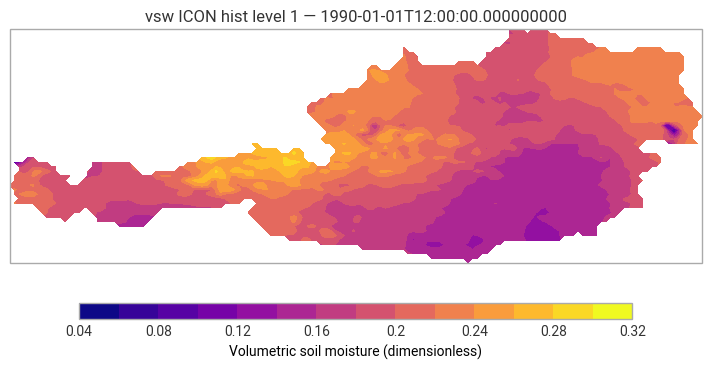

In [12]:
import io
import xarray as xr
import earthkit.plots as ekp

path = "destine-climate-dt/vsw/netcdf/ICON/vsw_ICON_hist_level1_1990-1990.nc"
with eodc_s3.open(path, "rb") as f:
    ds_check = xr.open_dataset(io.BytesIO(f.read()))

vsw_snapshot = ds_check["vsw"].isel(time=0)
ekp.quickplot(vsw_snapshot, title=f"vsw ICON hist level 1 — {vsw_snapshot['time'].values}")
